## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
df = pd.read_csv("cardio_train.csv", sep=';')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## Dataset Overview

In [3]:
df.shape
#70000 rows
#13 colums

(70000, 13)

In [4]:
df.columns
#all columns name

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

In [5]:
df.dtypes
#here all columns are numerical no categorical text data

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [7]:
#statastical summary
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


<h1>Week - 2</h1>

## Check Missing Values & Duplicates
Objective of TASK-2  

Clean the dataset

Handle outliers and incorrect values

Prepare data for machine learning

Understand feature relationships using EDA

In [8]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
#No missing values in dataset that's why no imputation required

## Convert Age (Days → Years)

In [11]:
df['age_years'] = (df['age'] / 365).astype(int)


In [12]:
df.drop('age', axis=1, inplace=True)


## Handleing Outliers

a) Blood Pressure Cleaning
Remove unrealistic blood pressure values:

ap_hi > 250 or ≤ 0

ap_lo > 200 or ≤ 0

ap_lo should be less than ap_hi

In [13]:
df = df[
    (df['ap_hi'] > 0) &
    (df['ap_hi'] < 250) &
    (df['ap_lo'] > 0) &
    (df['ap_lo'] < 200) &
    (df['ap_lo'] < df['ap_hi'])
]


b) Height and Weight Cleaning

In [14]:
df = df[
    (df['height'] > 120) & (df['height'] < 220) &
    (df['weight'] > 30) & (df['weight'] < 200)
]

In [15]:
#Unrealistic patient data removed
#Dataset becomes more reliable

## Data Pre-processing

Encoding Categorical Features

Already encoded numerically:

gender, cholesterol, gluc

smoke, alco, active

Hence: No additional encoding required.

## Feature Scaling

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df.drop('cardio', axis=1)
y = df['cardio']

X_scaled = scaler.fit_transform(X)

#Why Scaling?+
#Improves model performance
#Required for Logistic Regression

## Exploratory Data Analysis (EDA)

Target Variable Distribution

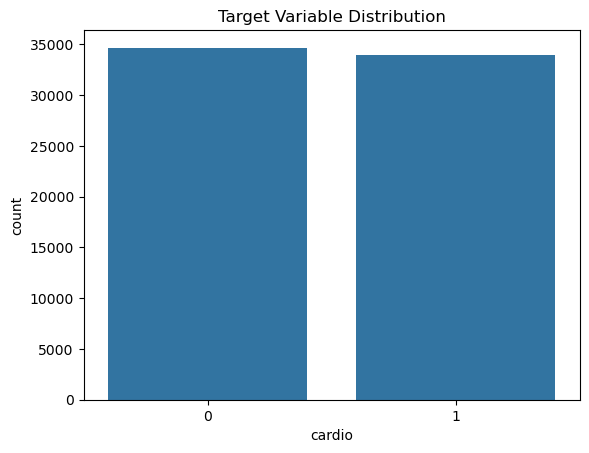

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='cardio', data=df)
plt.title("Target Variable Distribution")
plt.show()

In [18]:
#Classes are nearly balanced
#No class imbalance problem

Correlation Heatmap

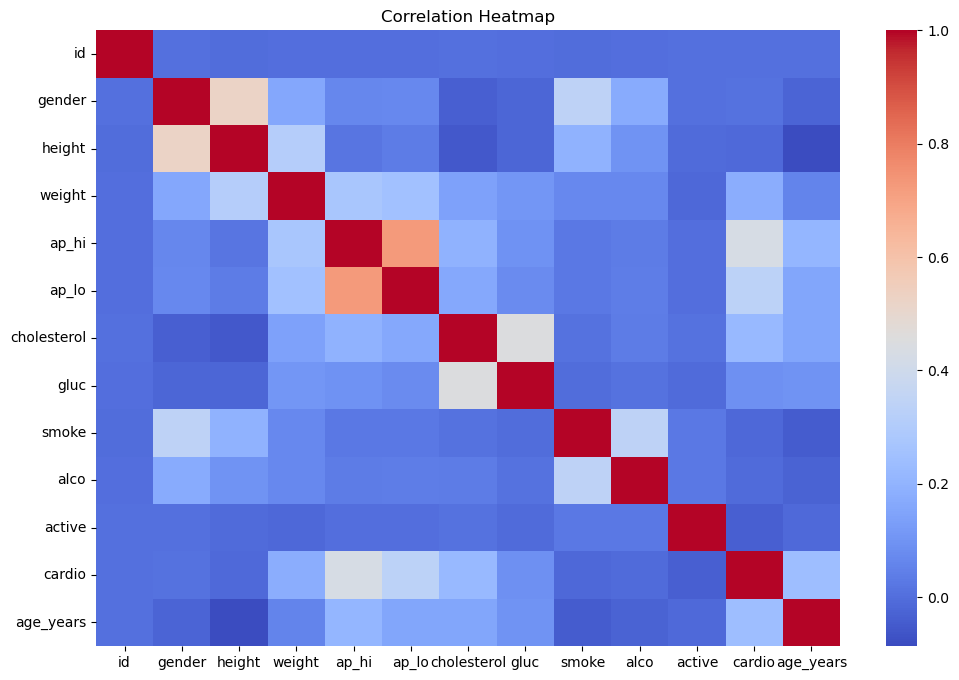

In [19]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Feature vs Target Analysis

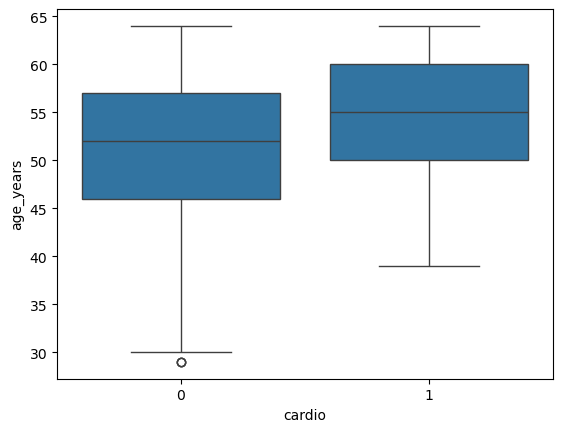

In [20]:
#age vs cardio
sns.boxplot(x='cardio', y='age_years', data=df)
plt.show()


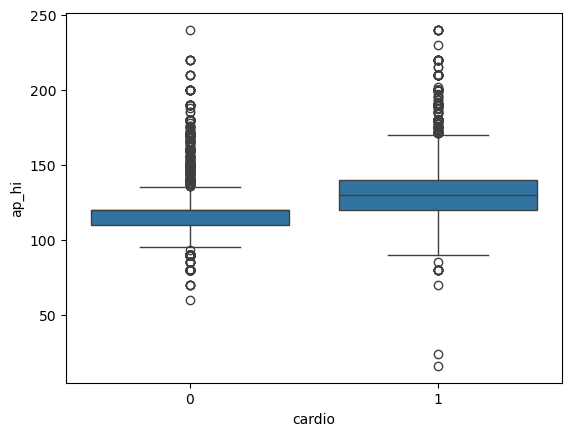

In [21]:
#age vs blood pressure
sns.boxplot(x='cardio', y='ap_hi', data=df)
plt.show()


## Task 3: Model Building from Scratch

## Train-Test Split

In [22]:
from sklearn.model_selection import train_test_split

X = df.drop('cardio', axis=1)
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Feature Scaling 

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Model Training using sklearn

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Model Prediction

In [25]:
y_pred = model.predict(X_test_scaled)


## Initial Accuracy Check

In [26]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.7285578955038986


<h1> Task 4 : Model Evaluation </h1>

## Confusion Matrix

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)


[[5523 1491]
 [2234 4475]]


## Classification Report

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.71      0.79      0.75      7014
           1       0.75      0.67      0.71      6709

    accuracy                           0.73     13723
   macro avg       0.73      0.73      0.73     13723
weighted avg       0.73      0.73      0.73     13723



## ROC Curve & AUC Score

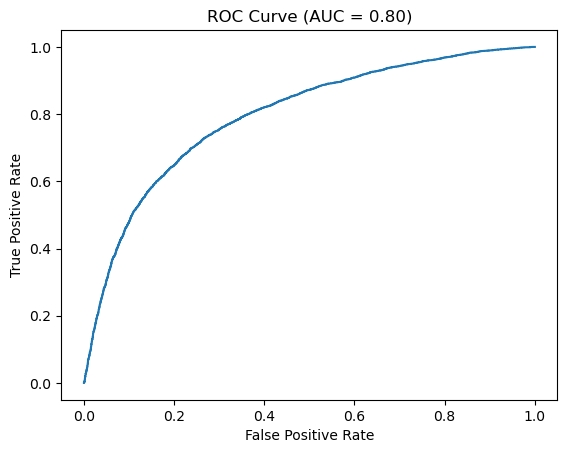

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc:.2f})")
plt.show()

## Overfitting / Underfitting Check


In [30]:
#Training vs Testing Accuracy
train_acc = model.score(X_train_scaled, y_train)
test_acc = model.score(X_test_scaled, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)


Training Accuracy: 0.7275559280040808
Testing Accuracy: 0.7285578955038986


In [31]:
#NO Overfitting
#Training accuracy ≈ Testing accuracy
#Difference is < 0.2%

In [32]:
#NO Underfitting
#Accuracy is not extremely low
#Model has learned meaningful patterns

## TASK-5: Advanced Model Training

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV


Cross-Validation

In [34]:
log_reg = LogisticRegression(max_iter=1000)

cv_scores = cross_val_score(
    log_reg,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


Cross-validation scores: [0.72345697 0.73088975 0.7265904  0.7300153  0.72396706]
Mean CV Accuracy: 0.7269838956496393


Train & Compare Multiple Models

In [35]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=5)
    print(f"{name} Mean Accuracy: {scores.mean():.3f}")


Logistic Regression Mean Accuracy: 0.727
Decision Tree Mean Accuracy: 0.587
Random Forest Mean Accuracy: 0.678
KNN Mean Accuracy: 0.695


In [36]:
#Logistic Regression fits this data 

Hyperparameter Tuning (GridSearchCV)

In [37]:
param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_scaled, y)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Parameters: {'C': 0.1}
Best CV Accuracy: 0.7270859141587117


Final Model Selection

In [38]:
best_model = grid.best_estimator_


## TASK-6: Visualization of Metrics & Graphs

Confusion Matrix Visualization

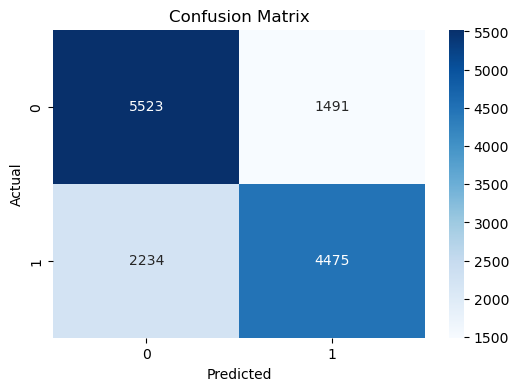

In [39]:
#Shows actual vs predicted values 

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


ROC Curve Visualization

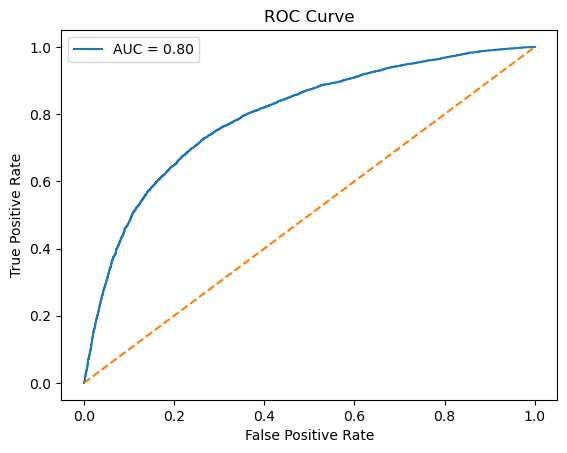

In [40]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


Precision–Recall Curve

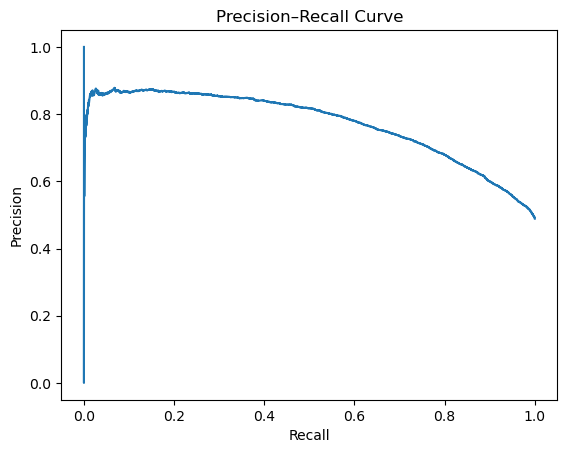

In [41]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()


Feature Importance / Coefficients

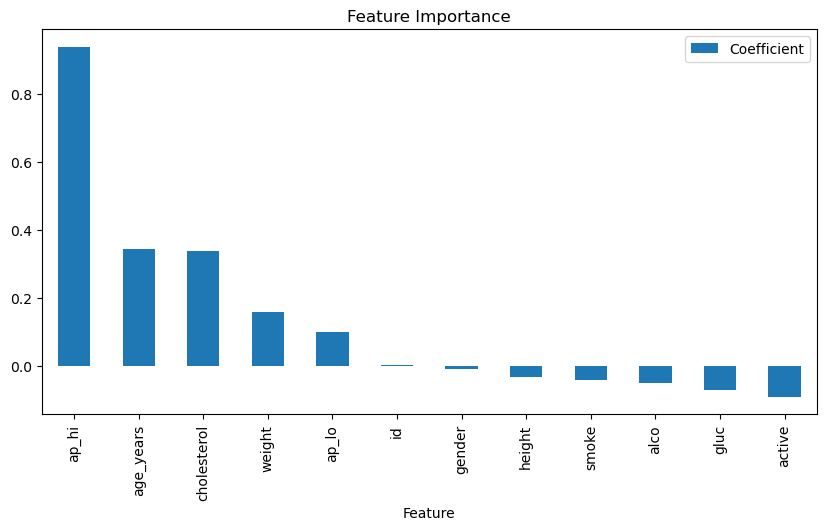

In [42]:
import pandas as pd
import numpy as np

features = X.columns
coefficients = best_model.coef_[0]

importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

importance.plot(
    x='Feature',
    y='Coefficient',
    kind='bar',
    figsize=(10,5),
    title='Feature Importance'
)
plt.show()


Model Comparison Visualization

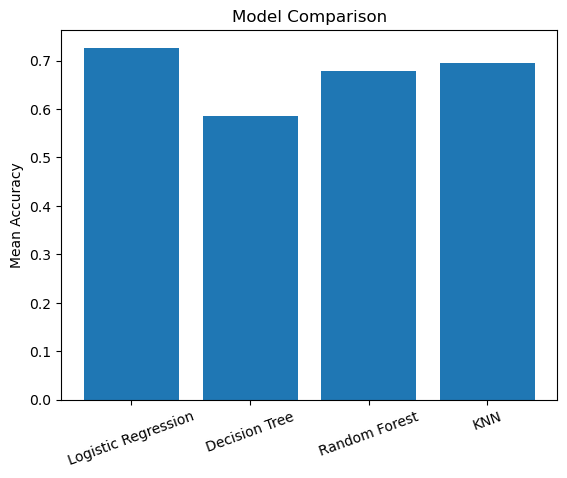

In [43]:
model_names = []
model_scores = []

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=5)
    model_names.append(name)
    model_scores.append(scores.mean())

plt.bar(model_names, model_scores)
plt.ylabel("Mean Accuracy")
plt.title("Model Comparison")
plt.xticks(rotation=20)
plt.show()


In [45]:
import pickle

# SAVE MODEL
with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# SAVE SCALER
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and Scaler saved successfully")


Model and Scaler saved successfully
